# Accessing Commissioning Data with ROSALIA 

## Introduction

This notebook demonstrates the use of ROSALIA to search data in MAST for commissioning data products, and then performing quick analyses.

This tutorial is based on been adapted from the Nexus tutorial [Streaming Products from S3 During Commissioning](https://github.com/spacetelescope/roman_notebooks/blob/main/notebooks/working_with_asdf/working_with_asdf.ipynb), with additional information added to support streaming from MAST search results.

## Imports

In [2]:
import rosalia as rs
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord  # High-level coordinates

ROSALIA assumes you have a valid MAST AUTH token to access the requested data.  

If you do not have a MAST AUTH token for accessing MAST (needed for Roman OPS access until after commissioning), or if your token has expired, make one now by visiting [MAST.Auth](https://auth.mast.stsci.edu/info).

Once you have a token, you can set it up as an environment variable for later use, or you can store it in a file called `variables.env`. Below, we have assumed the file is in your current working directory (`./`), but the full path to the file can be specified if it is stored elsewhere such as your home directory. The `variables.env` file should look like:

```
MAST_API_TOKEN='yourtokenhere'
```

Here we assume you stored it as an environment variable (recommended). The line to add to your .bashrc/.zshrc would look like:

```
export MAST_API_TOKEN='yourtokenhere'
```

In [ ]:
"""
Example of criteria for a roman_query using astroquery.mast.query_criteria
search = {'program': 1020,
         'observation': 5,
         'pass': 2, 
         #'exposure_start_time': '2026-09-15T02:01:47.4080000',
         'product_type': 'l2', 
         'detector': 'WFI06',
         # 'optical_element': 'F158',
         'exposure_type': "WFI_IMAGE"}

Here we use a region criteria, based on a set of coordinates and a search radius.
"""

coordinates=SkyCoord(229.64044*u.deg, -3.58747*u.deg, frame="icrs")
radius=10*u.arcsec

# query = roman_query_criteria(search=search, file_suffix="_cal")
results, products = rs.mast.roman_query(coordinates=coordinates, radius=radius, detector="WFI06", file_suffix="_cal")
data_stream = rs.mast.stream_roman_mast(products=products, row=0)
roman_exposure = rs.core.exposure(data_stream)

INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Mission: roman
Service: search
INFO: 228 of 364 products were duplicates. Only returning 136 unique product(s). [astroquery.mast.utils]
INFO: To return all products, use `MastMissions.get_product_list` [astroquery.mast.missions]
INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Filter F062 found in cache. Loading from /Users/aborlaff/NASA/rosalia_cache//CORE/filters/ROMAN_WFI_WFI_F062.pkl


2026-09-18T14:03:46.781035 > Fetching catalog


1it [00:00,  3.76it/s]

2026-09-18T14:03:47.612452 > Done.
2026-09-18T14:03:47.620392 > Starting Stray-light scan: 



100%|██████████| 1/1 [00:13<00:00, 13.07s/it]


2026-09-18T14:04:00.948738 > Done : 0:00:13.328363 elapsed.
 > Reconstructing the Stray-light / Main offender map: 
2026-09-18T14:04:01.008926 > Done : 
2026-09-18T14:04:01.600838 > Summary plots... 
Plot: Stray-light surface brightness magnitude.
DEMO WARNING: make_stray_plot is Assuming F129.
25
35


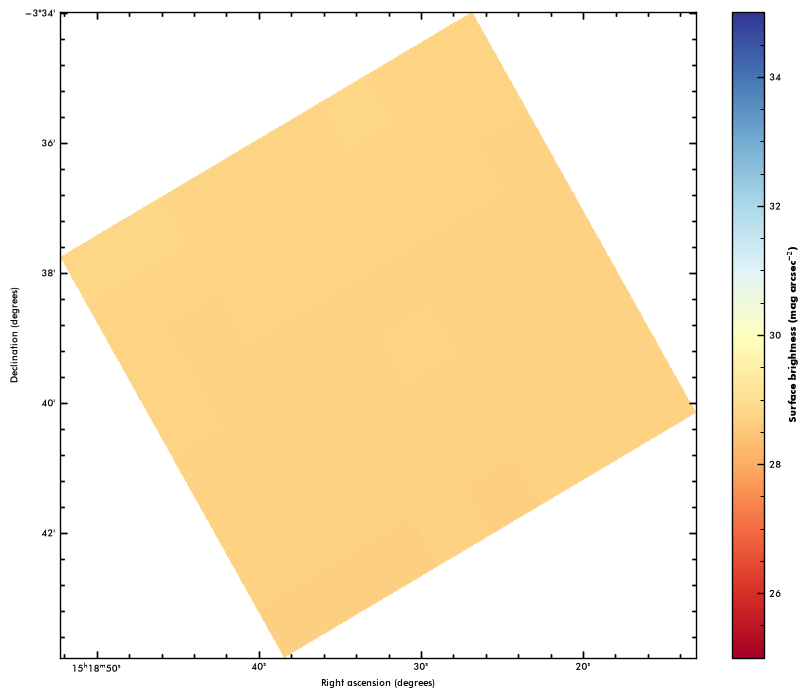

Plot: Stray-light surface brightness flux.
0.0014425968984141946
0.0015457614790648222


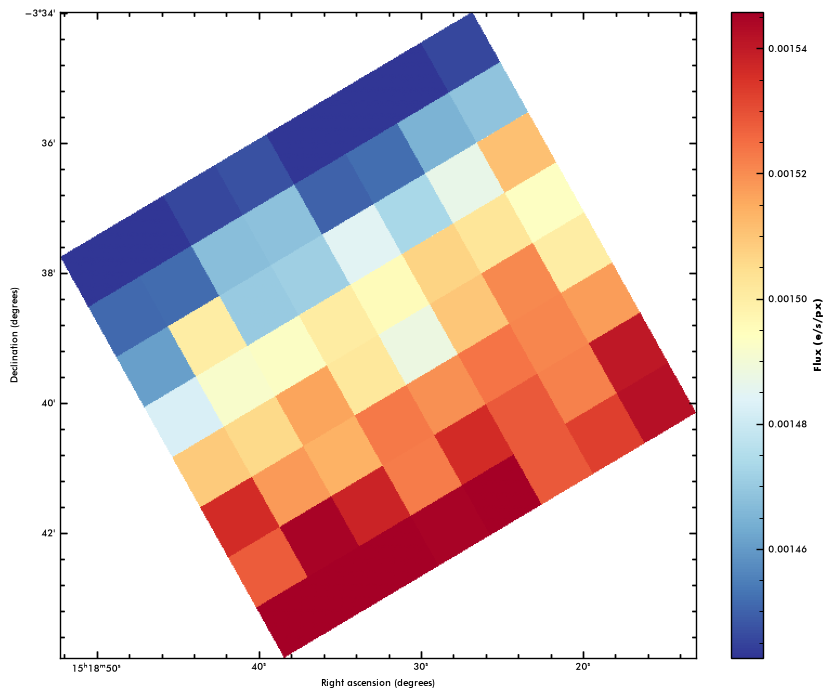

Plot: Main offender map.
9.0
395.0
Unique IDs:
[  3   4   5   6   7   8   9  12  17  18  25  26  31  36  46  51  53  54
  57  60  64  67  71  72  74  75  82  87  94  95 101 110 134 137 138 139
 140 144 147 154 155 158 159 162 166 170 178 182 184 185 187 217 222 223
 224 228 229 230 237 239 242 245 250 253 257 260 264 268 269 270 288 306
 307 308 312 326 327 334 335 336 337 340 343 347 352 353 354 371 382 391
 395]
Unique IDs with counts > 1:
[  3   4   5   6   7   8   9  12  60  64  71  95 101 147 178 185 260 269
 312 343 353 395]
Simbad cannot find the name of the offender at 207.68517 - -16.75721
Simbad cannot find the name of the offender at 167.59909 - 13.00245
Simbad cannot find the name of the offender at 138.91676 - 16.50036
Simbad cannot find the name of the offender at 101.28854 - -16.713142
Simbad cannot find the name of the offender at 186.62239 - -2.57763
* alf Car
Simbad cannot find the name of the offender at 213.91812 - 19.18727
Simbad cannot find the name of the offende

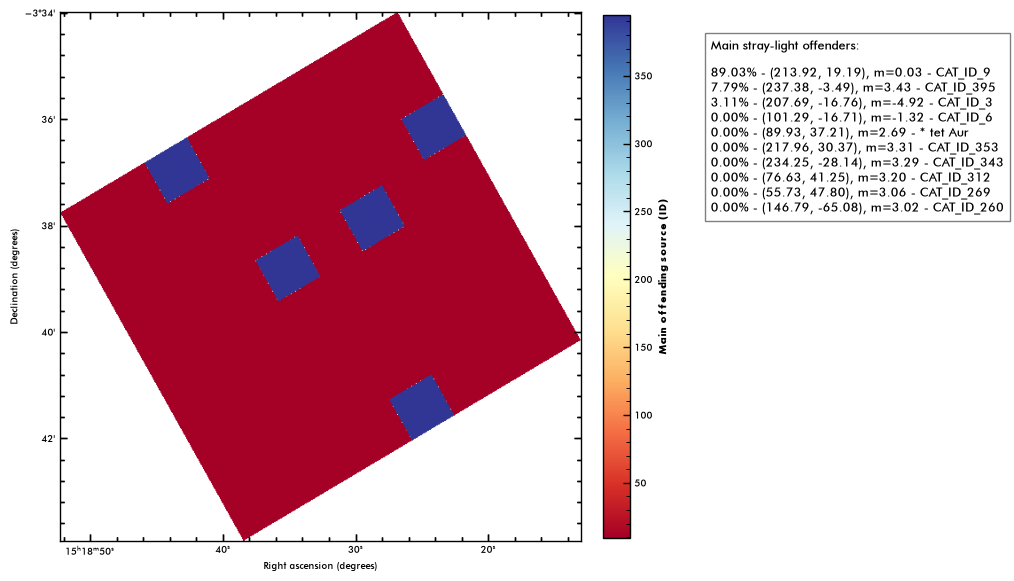

Plot: Source environment map.
SSO body: Sun not found. Skipping
SSO body: Moon not found. Skipping
SSO body: Earth not found. Skipping
SSO body: Mercury not found. Skipping
SSO body: Venus not found. Skipping
SSO body: Mars not found. Skipping
SSO body: Jupiter not found. Skipping
SSO body: Saturn not found. Skipping
SSO body: Uranus not found. Skipping
SSO body: Neptune not found. Skipping
SSO body: Pluto not found. Skipping


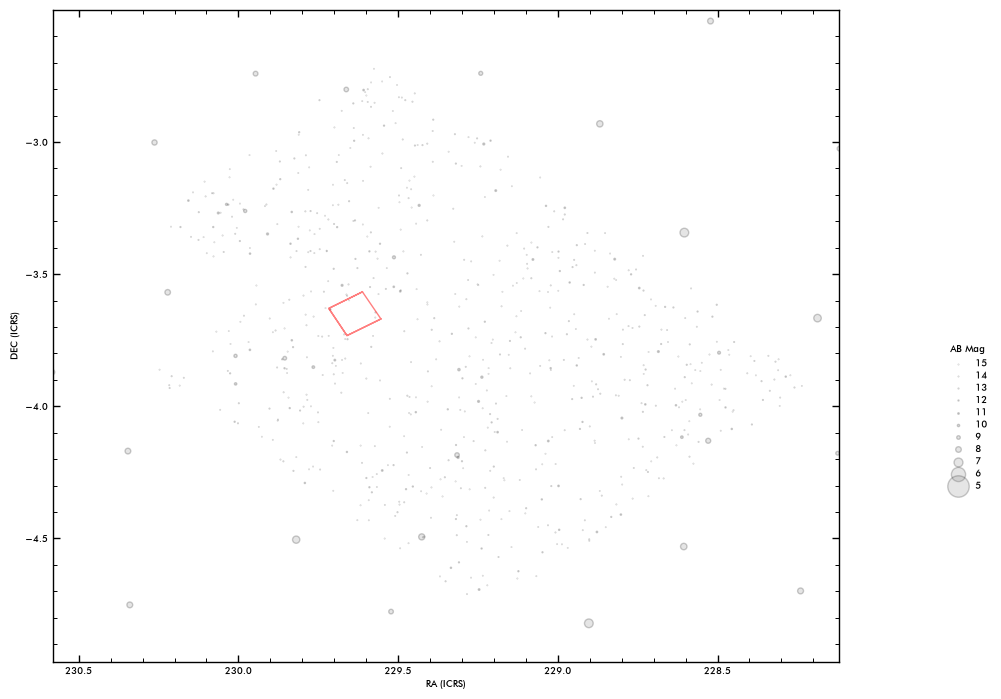

Plot: Location of Main offenders on NDI map.
Unique IDs:
[  3   4   5   6   7   8   9  12  17  18  25  26  31  36  46  51  53  54
  57  60  64  67  71  72  74  75  82  87  94  95 101 110 134 137 138 139
 140 144 147 154 155 158 159 162 166 170 178 182 184 185 187 217 222 223
 224 228 229 230 237 239 242 245 250 253 257 260 264 268 269 270 288 306
 307 308 312 326 327 334 335 336 337 340 343 347 352 353 354 371 382 391
 395]
Unique IDs with counts > 1:
[  3   4   5   6   7   8   9  12  60  64  71  95 101 147 178 185 260 269
 312 343 353 395]
Simbad cannot find the name of the offender at 207.68517 - -16.75721
Simbad cannot find the name of the offender at 167.59909 - 13.00245
Simbad cannot find the name of the offender at 138.91676 - 16.50036
Simbad cannot find the name of the offender at 101.28854 - -16.713142
Simbad cannot find the name of the offender at 186.62239 - -2.57763
* alf Car
Simbad cannot find the name of the offender at 213.91812 - 19.18727
Simbad cannot find the name of t

{'straylevel_db':     SCA  xmid  ymid       ramid    decmid  xmin  ymin  xmax  ymax  \
 0     6   255   255  229.614844 -3.576789     0     0   511   511   
 1     6   255   766  229.607652 -3.589639     0   511   511  1022   
 2     6   255  1277  229.600460 -3.602489     0  1022   511  1533   
 3     6   255  1788  229.593267 -3.615339     0  1533   511  2044   
 4     6   255  2299  229.586075 -3.628189     0  2044   511  2555   
 ..  ...   ...   ...         ...       ...   ...   ...   ...   ...   
 59    6  3832  1788  229.685907 -3.670331  3577  1533  4088  2044   
 60    6  3832  2299  229.678715 -3.683182  3577  2044  4088  2555   
 61    6  3832  2810  229.671523 -3.696032  3577  2555  4088  3066   
 62    6  3832  3321  229.664331 -3.708883  3577  3066  4088  3577   
 63    6  3832  3832  229.657139 -3.721733  3577  3577  4088  4088   
 
     straylight_total  mainoffender_total  
 0           0.001446                 9.0  
 1           0.001469                 9.0  
 2       

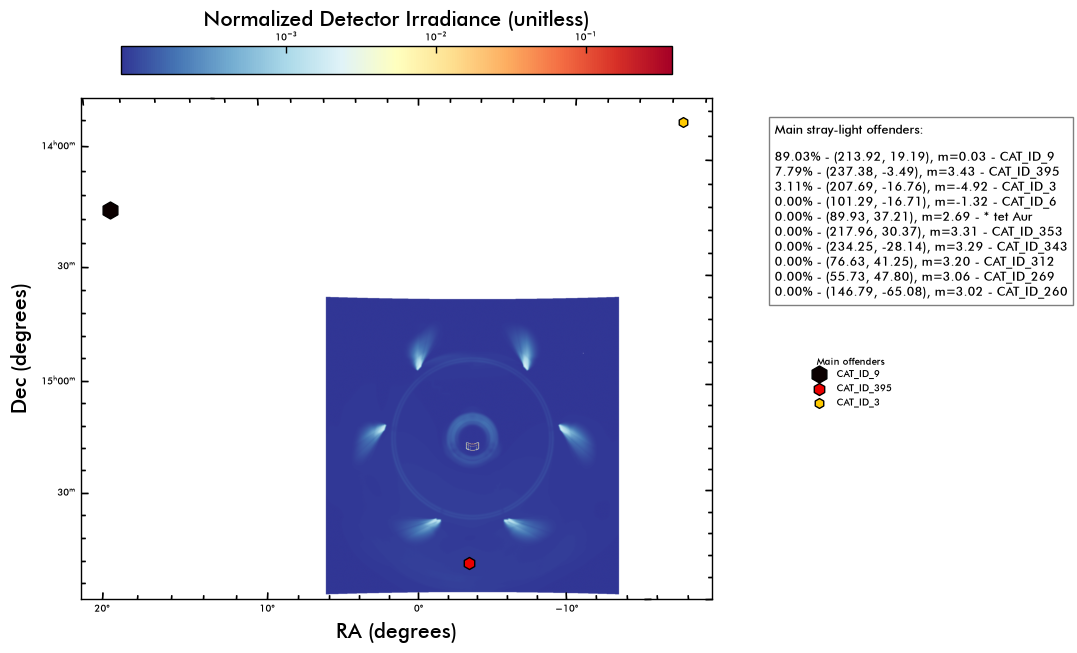

In [ ]:
# Let's demostrate the use of ROSALIA to estimate stray-light
# During commissioning, the astrometry might be off by a substantial angular distance. 
# Use only for testing purposes. 
roman_exposure.straylight()

In [5]:
roman_exposure.save_drz(outname="dragon_drz.fits", resolution=0.11)

(array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(5421, 5337)),
 WCSAXES =                    2 / Number of coordinate axes                      
 CRPIX1  =      2669.0726393037 / Pixel coordinate of reference point            
 CRPIX2  =      2711.1544990079 / Pixel coordinate of reference point            
 CDELT1  = -3.0555555555556E-05 / [deg] Coordinate increment at reference point  
 CDELT2  =  3.0555555555556E-05 / [deg] Coordinate increment at reference point  
 CUNIT1  = 'deg'                / Units of coordinate increment and value        
 CUNIT2  = 'deg'                / Units of coordinate increment and value        
 CTYPE1  = 'RA---TAN'           / Right ascension, gnomonic projection           
 CTYPE2  = 'DEC--TAN'           / Decli

In [ ]:
roman_exposure.make_close_stars_ds9_region(radius=5, output="nearby_stars.reg")

NameError: name 'close_catalog' is not defined